In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 1. Pull the maximum available data
ticker = "BTC-USD"
df = yf.download(ticker, period="max")

# 2. Engineer Features (RSI)
window = 14
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)
ema_up = up.ewm(com=window-1, adjust=False).mean()
ema_down = down.ewm(com=window-1, adjust=False).mean()
rs = ema_up / ema_down
df['RSI'] = 100 - (100 / (1 + rs))

# 3. Engineer Features (Bollinger Bands)
df['MA20'] = df['Close'].rolling(window=20).mean()
df['STD20'] = df['Close'].rolling(window=20).std()
df['Upper_Band'] = df['MA20'] + (df['STD20'] * 2)
df['Lower_Band'] = df['MA20'] - (df['STD20'] * 2)

# 4. Data Scientist "Target" Column (Did price go up the next day?)
# Useful for training your Pattern Recognition Model
df['Target_Next_Day_Up'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 5. Save to CSV
df.to_csv('bitcoin_pattern_recognition_data.csv')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head(30)

Price,Close,High,Low,Open,Volume,RSI,MA20,STD20,Upper_Band,Lower_Band,Target_Next_Day_Up
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1
2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600,3.963347,NaN,NaN,NaN,NaN,1
2014-09-23,435.790985,441.557007,396.196991,402.092010,45099500,12.107304,NaN,NaN,NaN,NaN,0
2014-09-24,423.204987,436.112000,421.131989,435.751007,30627700,11.707282,NaN,NaN,NaN,NaN,0


In [ ]:
df.isnull().sum()

Price               Ticker 
Close               BTC-USD     0
High                BTC-USD     0
Low                 BTC-USD     0
Open                BTC-USD     0
Volume              BTC-USD     0
RSI                             1
MA20                           19
STD20                          19
Upper_Band                     19
Lower_Band                     19
Target_Next_Day_Up              0
dtype: int64

In [ ]:
df.columns = df.columns.set_levels(
    [level.str.lower() for level in df.columns.levels]
)

In [ ]:
df.columns

MultiIndex([(             'close', 'btc-usd'),
            (              'high', 'btc-usd'),
            (               'low', 'btc-usd'),
            (              'open', 'btc-usd'),
            (            'volume', 'btc-usd'),
            (               'rsi',        ''),
            (              'ma20',        ''),
            (             'std20',        ''),
            (        'upper_band',        ''),
            (        'lower_band',        ''),
            ('target_next_day_up',        '')],
           names=['Price', 'Ticker'])

In [ ]:
df.head()

Price,close,high,low,open,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Ticker,btc-usd,btc-usd,btc-usd,btc-usd,btc-usd,,,,,,
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1


In [ ]:
df.columns = df.columns.droplevel(1)

In [ ]:
df.head()

Price,close,high,low,open,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Date,,,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,NaN,NaN,NaN,NaN,NaN,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0.000000,NaN,NaN,NaN,NaN,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0.000000,NaN,NaN,NaN,NaN,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,3.215775,NaN,NaN,NaN,NaN,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,3.138104,NaN,NaN,NaN,NaN,1


In [ ]:
df = df.rename(columns={
    'close': 'close_price',
    'high': 'high_price',
    'low': 'low_price',
    'open': 'open_price'
})

In [ ]:
df = df.dropna(axis=0) # drop missing values

In [ ]:
df

Price,close_price,high_price,low_price,open_price,volume,rsi,ma20,std20,upper_band,lower_band,target_next_day_up
Date,,,,,,,,,,,
2014-10-06,330.079010,345.134003,302.559998,320.389008,79011800,13.923041,389.910399,35.558666,461.027732,318.793066,1
2014-10-07,336.187012,339.247009,320.481995,330.584015,49199900,16.102590,383.853049,33.740796,451.334641,316.371457,1
2014-10-08,352.940002,354.364014,327.187988,336.115997,54736300,21.940826,380.278049,32.993690,446.265429,314.290669,1
2014-10-09,365.026001,382.726013,347.687012,352.747986,83641104,25.944557,378.789549,32.975772,444.741094,312.838004,0
2014-10-10,361.562012,375.066986,352.963013,364.687012,43665700,25.540219,376.422450,32.394343,441.211135,311.633765,1
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-26,78657.539062,78923.562500,77334.890625,77613.117188,21482934750,65.183076,74968.686719,2490.402837,79949.492392,69987.881045,0
2026-04-27,77366.625000,79488.171875,76481.343750,78661.015625,38135631927,59.853236,75239.982813,2438.176750,80116.336313,70363.629312,0
2026-04-28,76350.671875,77483.867188,75673.601562,77368.117188,32056900880,55.974163,75501.348437,2246.285979,79993.920396,71008.776479,0


In [ ]:
df.close_price.describe()

count      4225.000000
mean      28358.039409
std       32296.015438
min         178.102997
25%        3486.181641
50%       11488.363281
75%       45137.769531
max      124752.531250
Name: close_price, dtype: float64

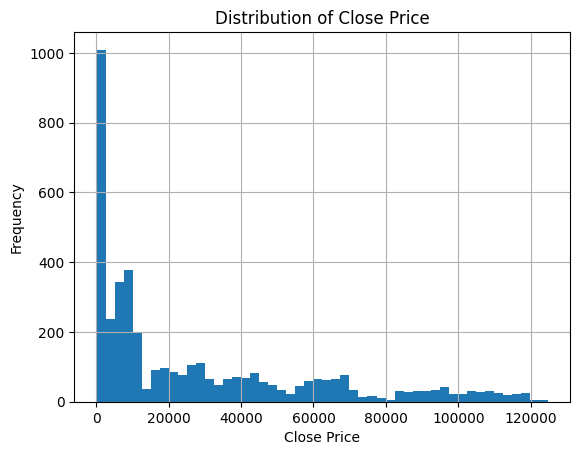

In [ ]:
df['close_price'].hist(bins=50)
plt.title('Distribution of Close Price')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='Date'>

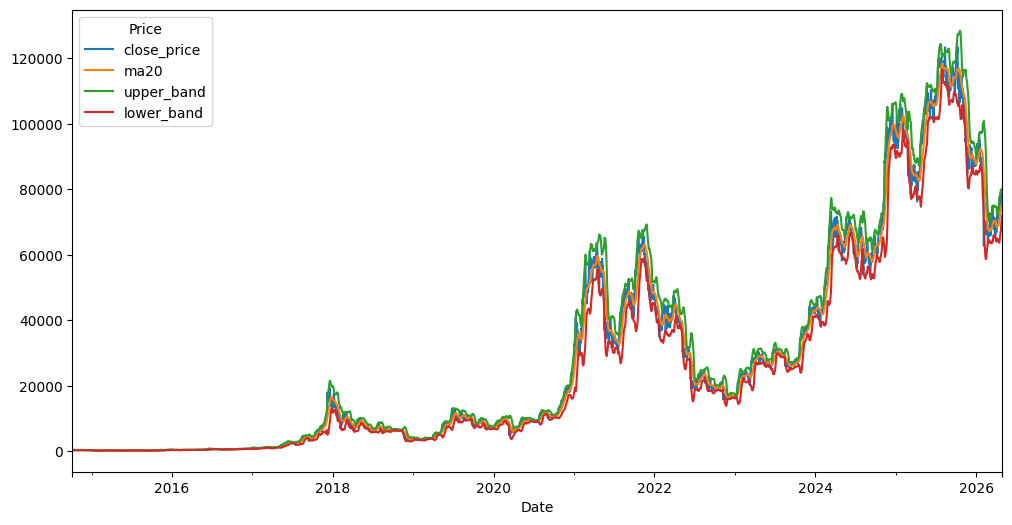

In [ ]:
df[['close_price', 'ma20', 'upper_band', 'lower_band']].plot(figsize=(12,6))

<Axes: >

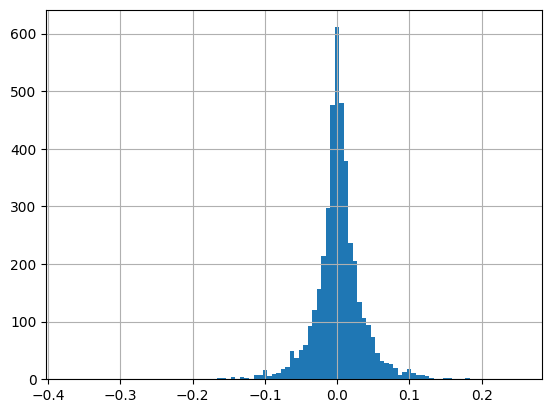

In [ ]:
df['close_price'].pct_change().hist(bins=100)

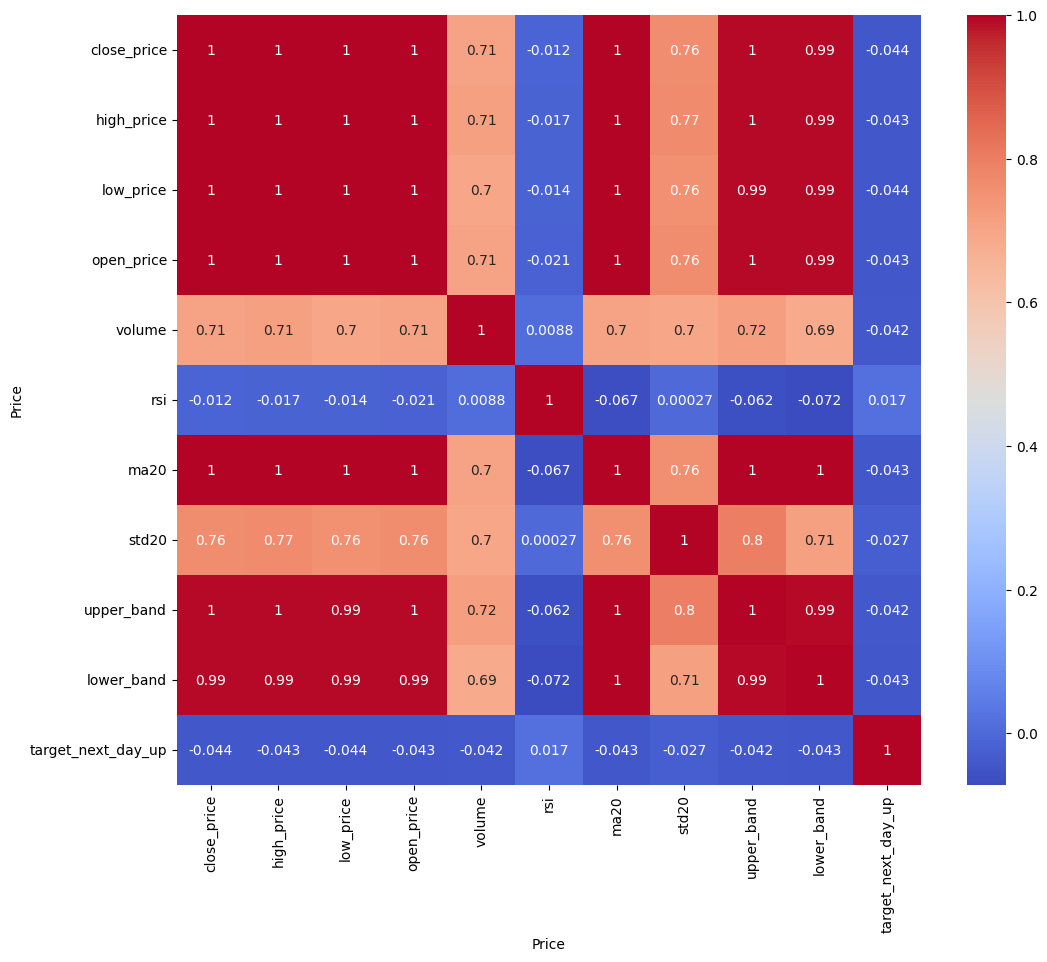

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [ ]:
df.groupby('target_next_day_up')['rsi'].mean()

target_next_day_up
0    52.759651
1    53.243290
Name: rsi, dtype: float64

In [ ]:
df.target_next_day_up.value_counts()

target_next_day_up
1    2222
0    2003
Name: count, dtype: int64

In [ ]:
(df[(df['rsi'] < 30)]['target_next_day_up'].mean())

np.float64(0.632258064516129)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

features = df[['rsi', 'ma20', 'std20', 'volume']]
target = df['target_next_day_up']

model = RandomForestClassifier()
model.fit(features, target)

print(model.feature_importances_)

[0.25882463 0.24257805 0.24615008 0.25244724]


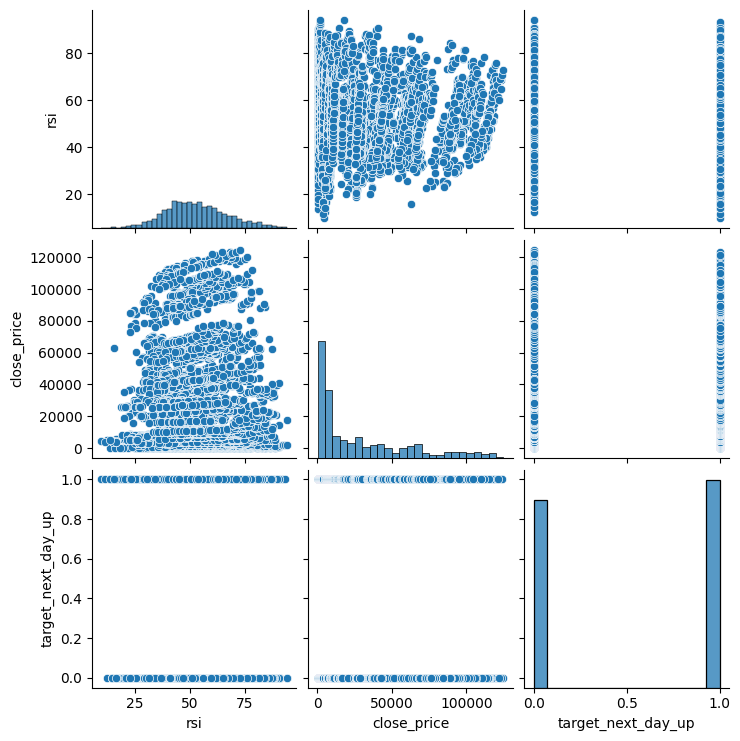

In [ ]:
sns.pairplot(df[['rsi', 'close_price', 'target_next_day_up']])

### Feature Engineering

In [ ]:
df['return_1'] = df['close_price'].pct_change()
df['return_1']

Date
2014-10-06         NaN
2014-10-07    0.018505
2014-10-08    0.049832
2014-10-09    0.034244
2014-10-10   -0.009490
                ...   
2026-04-26    0.013471
2026-04-27   -0.016412
2026-04-28   -0.013132
2026-04-29   -0.007525
2026-04-30    0.009476
Name: return_1, Length: 4225, dtype: float64

In [ ]:
df['hl_range'] = (df['high_price'] - df['low_price']) / df['close_price']

In [ ]:
df['hl_range']

Date
2014-10-06    0.128981
2014-10-07    0.055817
2014-10-08    0.076999
2014-10-09    0.095990
2014-10-10    0.061135
                ...   
2026-04-26    0.020197
2026-04-27    0.038865
2026-04-28    0.023710
2026-04-29    0.038619
2026-04-30    0.015736
Name: hl_range, Length: 4225, dtype: float64

In [ ]:
df['oc_change'] = (df['close_price'] - df['open_price']) / df['open_price']

In [ ]:
df['oc_change']

Date
2014-10-06    0.030244
2014-10-07    0.016949
2014-10-08    0.050054
2014-10-09    0.034807
2014-10-10   -0.008569
                ...   
2026-04-26    0.013457
2026-04-27   -0.016455
2026-04-28   -0.013151
2026-04-29   -0.007525
2026-04-30    0.009796
Name: oc_change, Length: 4225, dtype: float64

In [ ]:
df['body_size'] = abs(df['close_price'] - df['open_price']) / df['close_price']

In [ ]:
df['body_size'].head()

Date
2014-10-06    0.029357
2014-10-07    0.016666
2014-10-08    0.047668
2014-10-09    0.033636
2014-10-10    0.008643
Name: body_size, dtype: float64

### Trend Features

In [ ]:
df['ma_ratio'] = df['close_price'] / df['ma20']
df['ma_ratio'] # Above 1 -> bullish trend , Below 1 -> bearish

Date
2014-10-06    0.846551
2014-10-07    0.875822
2014-10-08    0.928110
2014-10-09    0.963664
2014-10-10    0.960522
                ...   
2026-04-26    1.049205
2026-04-27    1.028265
2026-04-28    1.011249
2026-04-29    1.000982
2026-04-30    1.008128
Name: ma_ratio, Length: 4225, dtype: float64

In [ ]:
df['ma_slope'] = df['ma20'].diff() # Direction of trend (rising or falling)
df['ma_slope']

Date
2014-10-06           NaN
2014-10-07     -6.057350
2014-10-08     -3.575000
2014-10-09     -1.488499
2014-10-10     -2.367099
                 ...    
2026-04-26    489.885547
2026-04-27    271.296094
2026-04-28    261.365625
2026-04-29    200.415234
2026-04-30    175.758594
Name: ma_slope, Length: 4225, dtype: float64

<Axes: xlabel='Date'>

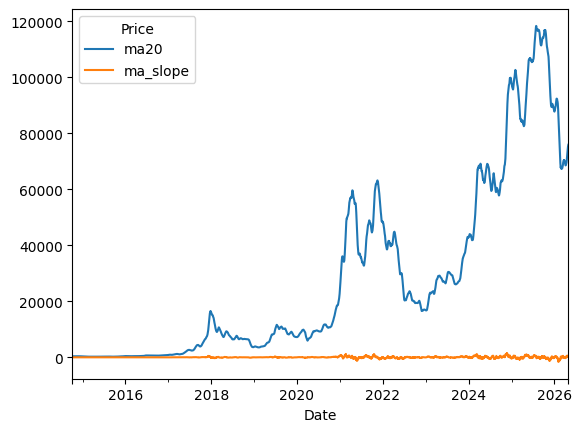

In [ ]:
df[["ma20", "ma_slope"]].plot()

In [ ]:
df['price_vs_ma'] = df['close_price'] - df['ma20'] # Distance from trend (overextended or not)
df['price_vs_ma'].tail()

Date
2026-04-26    3688.852344
2026-04-27    2126.642187
2026-04-28     849.323438
2026-04-29      74.369141
2026-04-30     616.696484
Name: price_vs_ma, dtype: float64

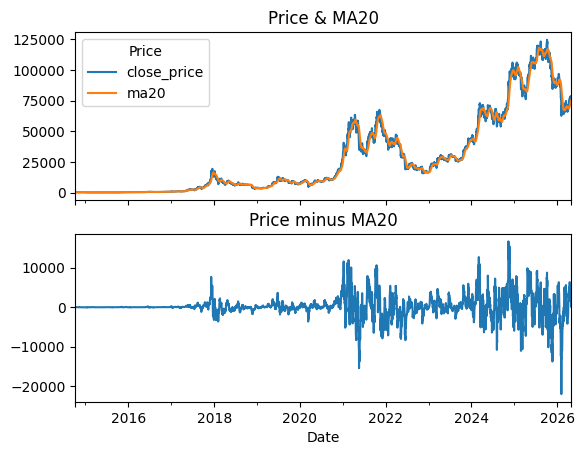

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True)

df[["close_price", "ma20"]].plot(ax=axes[0], title="Price & MA20")
df["price_vs_ma"].plot(ax=axes[1], title="Price minus MA20")

plt.show()

### Volatility features

In [ ]:
df['volatility'] = df['std20'] #Already given — measures market instability

<Axes: >

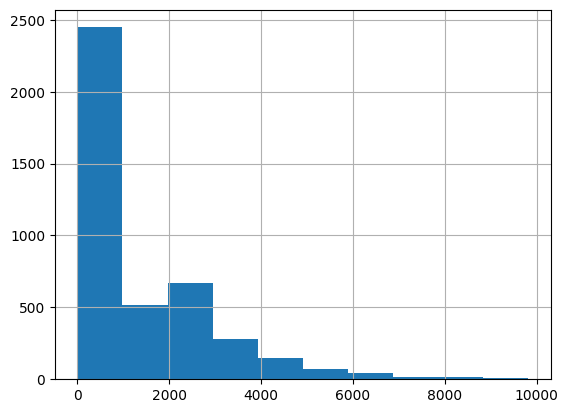

In [ ]:
df['volatility'].hist()

In [ ]:
df['volatility_change'] = df['std20'].pct_change() # Detects volatility expansion (before big moves)
df['volatility_change'].describe()

count    4224.000000
mean        0.007026
std         0.118983
min        -0.534495
25%        -0.045120
50%        -0.000108
75%         0.045511
max         2.019265
Name: volatility_change, dtype: float64

### Bollinger Band Features

In [ ]:
df['bb_position'] = (df['close_price'] - df['lower_band']) / (df['upper_band'] - df['lower_band'])

# 0 -> bottom
# 1-> top

df['bb_position'].describe()

count    4225.000000
mean        0.548364
std         0.328643
min        -0.490364
25%         0.297039
50%         0.556445
75%         0.812495
max         1.515963
Name: bb_position, dtype: float64

<Axes: >

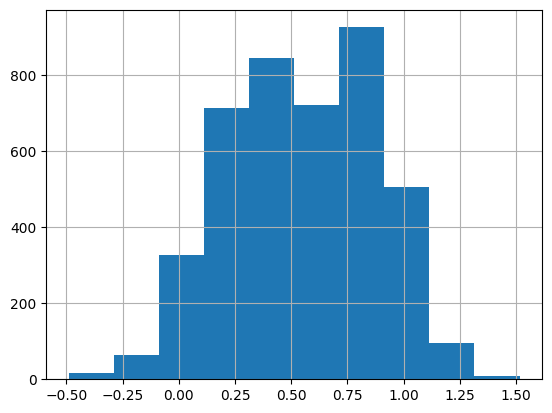

In [ ]:
df['bb_position'].hist()

<Axes: >

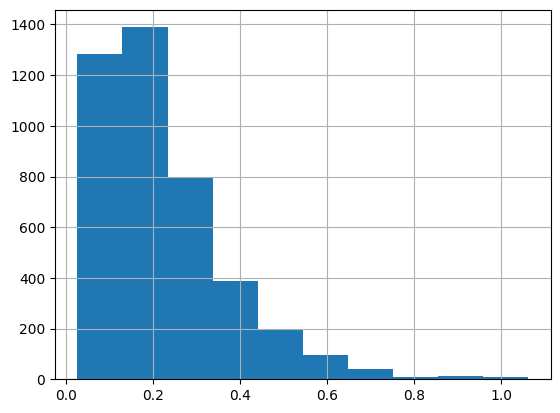

In [ ]:
df['bb_width'] = (df['upper_band'] - df['lower_band']) / df['ma20'] 

# Narrow -> breakout coming
# Wide -> volatile market
df['bb_width'].hist()

In [ ]:
df['bb_breakout_up'] = (df['close_price'] > df['upper_band']).astype(int)
df['bb_breakout_down'] = (df['close_price'] < df['lower_band']).astype(int) # strong breakout signals

### RSI features

In [ ]:
df['rsi_overbought'] = (df['rsi'] > 70).astype(int)
df['rsi_oversold'] = (df['rsi'] < 30).astype(int)

In [ ]:
df['rsi_overbought'].value_counts()

rsi_overbought
0    3700
1     525
Name: count, dtype: int64

In [ ]:
df['rsi_oversold'].value_counts()

rsi_oversold
0    4070
1     155
Name: count, dtype: int64

<Axes: >

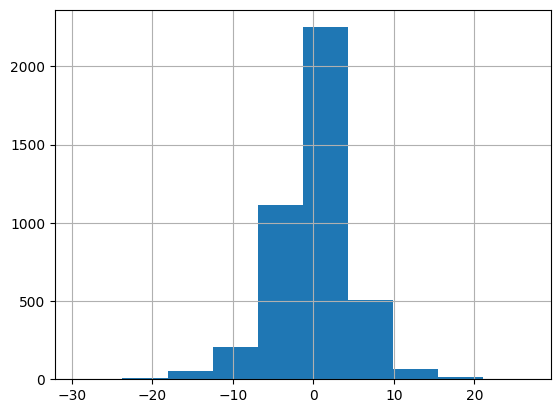

In [ ]:
df['rsi_change'] = df['rsi'].diff() # Momentum shift
df['rsi_change'].hist()

In [ ]:
df['rsi_ma_interaction'] = df['rsi'] * df['ma_ratio'] # Nonlinear pattern (very useful)

In [ ]:
df['volume_change'] = df['volume'].pct_change() # Sudden interest in market

In [ ]:
df['volume_spike'] = (df['volume'] > df['volume'].rolling(20).mean()).astype(int) # Unusual activity → often precedes moves

In [ ]:
df['price_volume'] = df['return_1'] * df['volume'] #Combines price + conviction

In [ ]:
df.isnull().sum()

Price
close_price           0
high_price            0
low_price             0
open_price            0
volume                0
rsi                   0
ma20                  0
std20                 0
upper_band            0
lower_band            0
target_next_day_up    0
return_1              1
hl_range              0
oc_change             0
body_size             0
ma_ratio              0
ma_slope              1
price_vs_ma           0
volatility            0
volatility_change     1
bb_position           0
bb_width              0
bb_breakout_up        0
bb_breakout_down      0
rsi_overbought        0
rsi_oversold          0
rsi_change            1
rsi_ma_interaction    0
volume_change         1
volume_spike          0
price_volume          1
dtype: int64

In [ ]:
df

Price,close_price,high_price,low_price,open_price,volume,rsi,ma20,std20,upper_band,lower_band,...,bb_width,bb_breakout_up,bb_breakout_down,rsi_overbought,rsi_oversold,rsi_change,rsi_ma_interaction,volume_change,volume_spike,price_volume
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-06,330.079010,345.134003,302.559998,320.389008,79011800,13.923041,389.910399,35.558666,461.027732,318.793066,...,0.364788,0,0,0,1,NaN,11.786563,NaN,0,NaN
2014-10-07,336.187012,339.247009,320.481995,330.584015,49199900,16.102590,383.853049,33.740796,451.334641,316.371457,...,0.351601,0,0,0,1,2.179549,14.103006,-0.377309,0,9.104277e+05
2014-10-08,352.940002,354.364014,327.187988,336.115997,54736300,21.940826,380.278049,32.993690,446.265429,314.290669,...,0.347048,0,0,0,1,5.838235,20.363508,0.112529,0,2.727639e+06
2014-10-09,365.026001,382.726013,347.687012,352.747986,83641104,25.944557,378.789549,32.975772,444.741094,312.838004,...,0.348223,0,0,0,1,4.003731,25.001845,0.528074,0,2.864187e+06
2014-10-10,361.562012,375.066986,352.963013,364.687012,43665700,25.540219,376.422450,32.394343,441.211135,311.633765,...,0.344234,0,0,0,1,-0.404338,24.531940,-0.477940,0,-4.143746e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-26,78657.539062,78923.562500,77334.890625,77613.117188,21482934750,65.183076,74968.686719,2490.402837,79949.492392,69987.881045,...,0.132877,0,0,0,0,2.499038,68.390424,0.286177,0,2.893999e+08
2026-04-27,77366.625000,79488.171875,76481.343750,78661.015625,38135631927,59.853236,75239.982813,2438.176750,80116.336313,70363.629312,...,0.129621,0,0,0,0,-5.329840,61.544975,0.775159,1,-6.258755e+08
2026-04-28,76350.671875,77483.867188,75673.601562,77368.117188,32056900880,55.974163,75501.348437,2246.285979,79993.920396,71008.776479,...,0.119006,0,0,0,0,-3.879073,56.603823,-0.159398,0,-4.209607e+08


<Axes: xlabel='Price', ylabel='Price'>

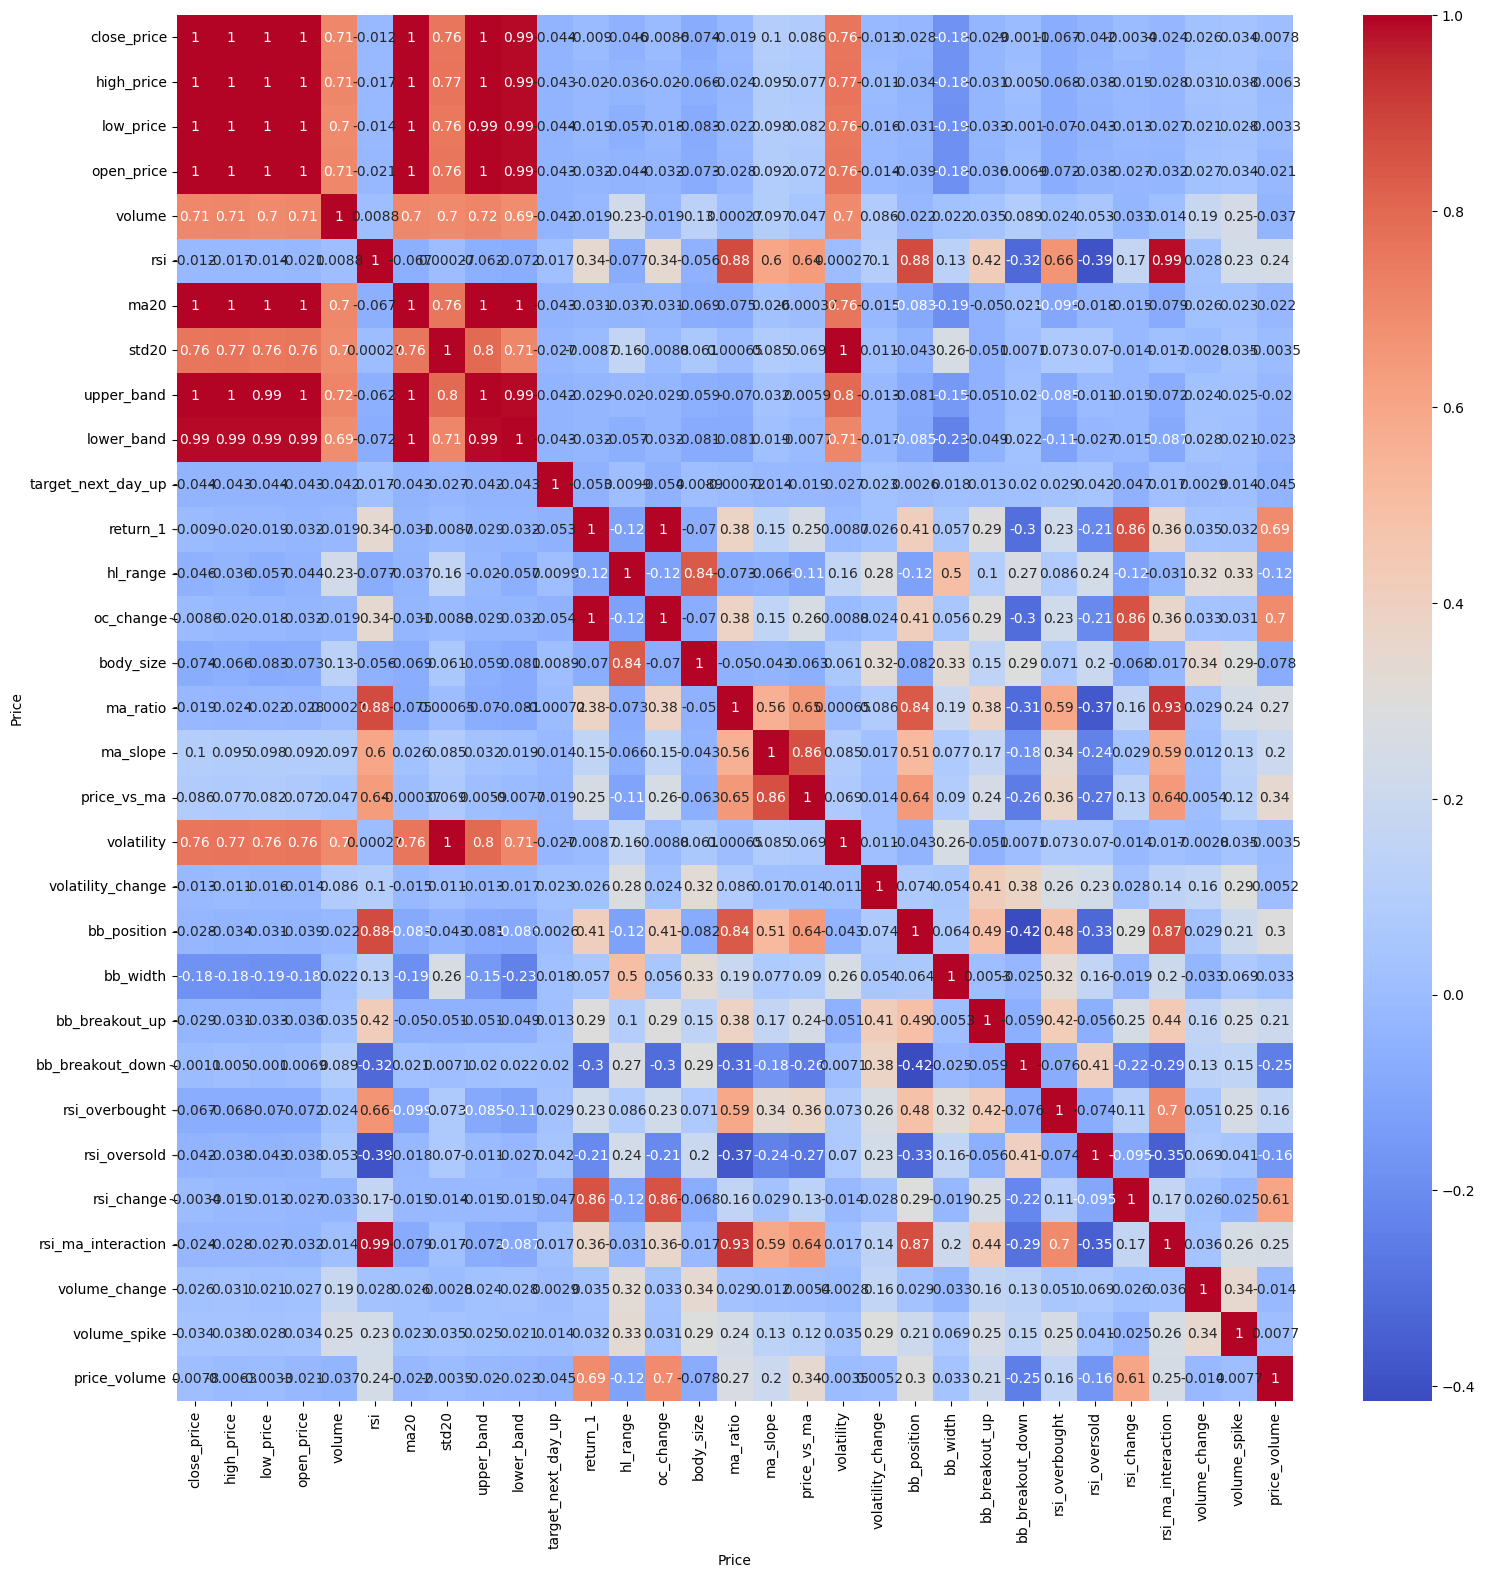

In [ ]:
plt.figure(figsize=(18, 18))

corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [ ]:
df.isnull().sum()

Price
close_price           0
high_price            0
low_price             0
open_price            0
volume                0
rsi                   0
ma20                  0
std20                 0
upper_band            0
lower_band            0
target_next_day_up    0
return_1              1
hl_range              0
oc_change             0
body_size             0
ma_ratio              0
ma_slope              1
price_vs_ma           0
volatility            0
volatility_change     1
bb_position           0
bb_width              0
bb_breakout_up        0
bb_breakout_down      0
rsi_overbought        0
rsi_oversold          0
rsi_change            1
rsi_ma_interaction    0
volume_change         1
volume_spike          0
price_volume          1
dtype: int64